In [1]:
import sys
import importlib
# Reload environment so imports work immediately
importlib.invalidate_caches()

In [2]:
# CREDIT RISK (XGBoost + Optuna + SHAP)
import warnings, json, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay, confusion_matrix,
    roc_curve
)
from sklearn.utils import resample
import xgboost as xgb
import shap, optuna
import math


# Basic plotting style
sns.set(style="whitegrid")   
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100




# CONFIG 
RAW_CSV = "C:\\Users\\samar\\Downloads\\DS 340W\\Project Code\\foia-7a-fy2020-present-asof-250630.csv"  # update path if needed
TEST_SIZE = 0.2
SEED = 42
N_SAMPLES_CAP = 20000

# CLEANING 
def prep_foia_dataset(input_csv: str) -> pd.DataFrame:
    usecols = [
        "LoanStatus","Term","GrossApproval","SBAGuaranteedApproval",
        "JobsSupported","ApprovalDate","NAICSCode","BorrZip",
        "UrbanRural","BusinessType","LoanDeliveryMethod","FranchiseCode",
        "NonProfit","BorrState"
    ]
    df = pd.read_csv(
        input_csv,
        low_memory=False,
        dtype=str,
        usecols=lambda x: x in usecols
    )

    # Keep only Paid in Full vs Charged Off
    df = df[df["LoanStatus"].isin(["PIF", "CHGOFF"])].copy()
    # Target: 1 = CHGOFF (risky), 0 = PIF (non-risky)
    df["Risk"] = (df["LoanStatus"] == "CHGOFF").astype(int)

    def _to_num(s):
        return pd.to_numeric(
            s.str.replace(r"[^0-9.\-]", "", regex=True),
            errors="coerce"
        )

    for col in ["Term","GrossApproval","SBAGuaranteedApproval","JobsSupported"]:
        if col in df.columns:
            df[col] = _to_num(df[col].astype(str))

    if "ApprovalDate" in df.columns:
        df["ApprovalDate"] = pd.to_datetime(df["ApprovalDate"], errors="coerce")
        df["ApprovalYear"] = df["ApprovalDate"].dt.year
        df["ApprovalMonth"] = df["ApprovalDate"].dt.month

    if {"SBAGuaranteedApproval","GrossApproval"}.issubset(df.columns):
        df["sba_share"] = df["SBAGuaranteedApproval"] / df["GrossApproval"]

    if "NAICSCode" in df.columns:
        df["NAICS2"] = df["NAICSCode"].astype(str).str[:2]
    if "BorrZip" in df.columns:
        df["Zip3"] = df["BorrZip"].astype(str).str.extract(r"^(\d{3})")

    for col in [
        "UrbanRural","BusinessType","LoanDeliveryMethod","FranchiseCode",
        "NonProfit","BorrState","Zip3","NAICS2"
    ]:
        if col in df.columns:
            df[col] = df[col].astype("category")

    df = df.drop(columns=["LoanStatus"], errors="ignore")
    df = df.dropna(subset=["Risk"])

    # cap for speed
    if len(df) > N_SAMPLES_CAP:
        df = df.sample(N_SAMPLES_CAP, random_state=SEED)

    print(f"✅ Cleaned in memory: {len(df):,} rows, {df.shape[1]} features")
    return df

df_clean = prep_foia_dataset(RAW_CSV)
y = df_clean["Risk"].astype(int)
X = df_clean.drop(columns=["Risk"])

# CLASS-IMBALANCE HANDLING 
pos_ratio = y.mean()
neg_ratio = 1 - pos_ratio
scale_pos_weight = neg_ratio / max(pos_ratio, 1e-6)  # avoid divide-by-zero
print(f"📊 Positive class ratio (Risk=1): {pos_ratio:.3f}, scale_pos_weight: {scale_pos_weight:.2f}")








✅ Cleaned in memory: 20,000 rows, 15 features
📊 Positive class ratio (Risk=1): 0.076, scale_pos_weight: 12.15


In [3]:
# PREPROCESSOR 
cat_cols = X.select_dtypes(include=["object","category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number,"bool"]).columns.tolist()

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:  # older sklearn
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

pre = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scl", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", ohe)
    ]), cat_cols)
])

In [4]:
# FASTER TUNING SUBSET 
X_tune, y_tune = resample(
    X, y,
    n_samples=min(8000, len(X)),  # tune on up to 8k rows
    random_state=SEED,
    stratify=y
)

In [5]:
# OPTUNA TUNING 
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "n_estimators": trial.suggest_int("n_estimators", 100, 250),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "eval_metric": "logloss",
        "use_label_encoder": False,
        "random_state": SEED,
        "tree_method": "hist",
        "base_score": 0.5,
        "scale_pos_weight": scale_pos_weight,
        "n_jobs": -1,
    }

    model = xgb.XGBClassifier(**params)
    pipe_cv = Pipeline([("pre", pre), ("clf", model)])

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    aucs = []

    for train_idx, val_idx in cv.split(X_tune, y_tune):
        X_train_cv, X_val_cv = X_tune.iloc[train_idx], X_tune.iloc[val_idx]
        y_train_cv, y_val_cv = y_tune.iloc[train_idx], y_tune.iloc[val_idx]
        pipe_cv.fit(X_train_cv, y_train_cv)
        preds = pipe_cv.predict_proba(X_val_cv)[:, 1]
        aucs.append(roc_auc_score(y_val_cv, preds))

    return float(np.mean(aucs))

print("🔍 Running Optuna hyperparameter tuning (4 trials for speed)...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=4, show_progress_bar=False)
best_params = study.best_params
print("✅ Best parameters from Optuna:")
print(json.dumps(best_params, indent=2))



[I 2025-12-01 22:24:30,691] A new study created in memory with name: no-name-281a8cb1-0efa-4d12-a6e9-991cdb344e23


🔍 Running Optuna hyperparameter tuning (4 trials for speed)...


[I 2025-12-01 22:25:01,837] Trial 0 finished with value: 0.8018849012804165 and parameters: {'max_depth': 4, 'learning_rate': 0.17448674647650902, 'subsample': 0.7915973663877436, 'colsample_bytree': 0.9452831610629993, 'n_estimators': 219, 'reg_lambda': 2.3152771691300313, 'reg_alpha': 2.8326784512815934e-06}. Best is trial 0 with value: 0.8018849012804165.
[I 2025-12-01 22:25:25,031] Trial 1 finished with value: 0.7985642787097148 and parameters: {'max_depth': 8, 'learning_rate': 0.16069116053954463, 'subsample': 0.9696568276668587, 'colsample_bytree': 0.7983924461526448, 'n_estimators': 128, 'reg_lambda': 2.330893379134286, 'reg_alpha': 0.003141207621899048}. Best is trial 0 with value: 0.8018849012804165.
[I 2025-12-01 22:25:57,842] Trial 2 finished with value: 0.7992627134810596 and parameters: {'max_depth': 7, 'learning_rate': 0.022668115179885956, 'subsample': 0.7285165489605931, 'colsample_bytree': 0.7584211784058861, 'n_estimators': 241, 'reg_lambda': 1.9017213857366282, 'reg_

✅ Best parameters from Optuna:
{
  "max_depth": 4,
  "learning_rate": 0.17448674647650902,
  "subsample": 0.7915973663877436,
  "colsample_bytree": 0.9452831610629993,
  "n_estimators": 219,
  "reg_lambda": 2.3152771691300313,
  "reg_alpha": 2.8326784512815934e-06
}


In [6]:
# TRAIN FINAL MODEL ON FULL DATA 
final_model = xgb.XGBClassifier(
    **best_params,
    use_label_encoder=False,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    tree_method="hist",
    base_score=0.5,
    n_jobs=-1
)

pipe = Pipeline([("pre", pre), ("clf", final_model)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=TEST_SIZE,
    random_state=SEED
)
pipe.fit(X_train, y_train)



,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


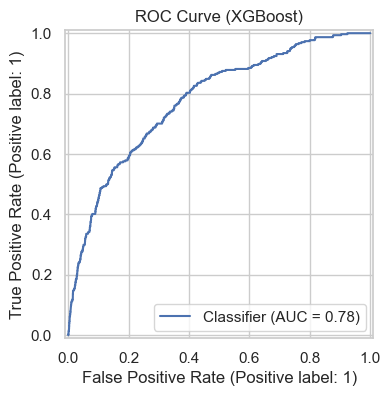

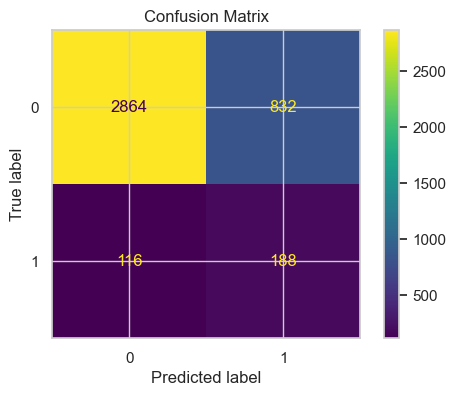


 RESULTS
{
  "accuracy": 0.763,
  "precision": 0.1843137254901961,
  "recall": 0.618421052631579,
  "f1": 0.283987915407855,
  "roc_auc": 0.777930266005924
}


In [7]:

# EVALUATION 
def evaluate_and_plot(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_score)
    }
    # FIGURE 11 – ROC curve of tuned XGBoost model
    RocCurveDisplay.from_predictions(y_test, y_score)
    plt.title("ROC Curve (XGBoost)")
    plt.show()
    
    # Figure 10 – Confusion matrix of tuned XGBoost (raw counts)
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(values_format="d")
    plt.title("Confusion Matrix")
    plt.show()

    return metrics, y_pred, y_score

metrics, y_pred, y_score = evaluate_and_plot(pipe, X_test, y_test)
print("\n RESULTS")
print(json.dumps(metrics, indent=2))


📊 Generating SHAP feature importances...


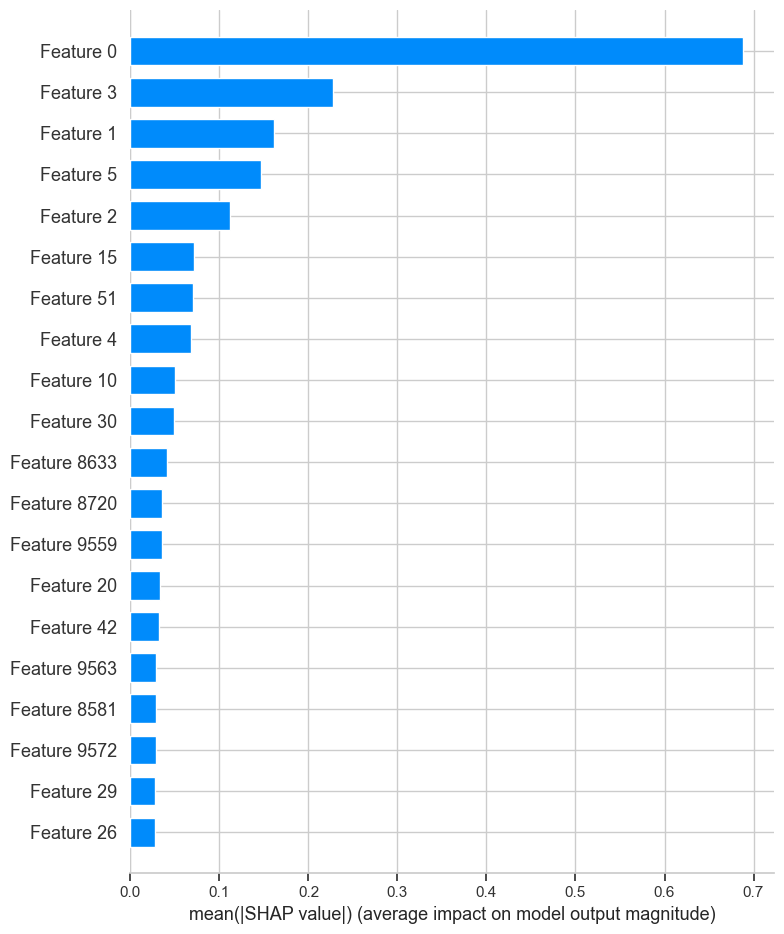

In [8]:
# SHAP EXPLAINABILITY 
print("\n📊 Generating SHAP feature importances...")
explainer = shap.TreeExplainer(final_model)
#  FIGURE 12 : Global SHAP feature importance for the tuned XGBoost model.
X_trans = pre.fit_transform(X_train)
shap_values = explainer.shap_values(X_trans)
shap.summary_plot(shap_values, X_trans, plot_type="bar", show=True)



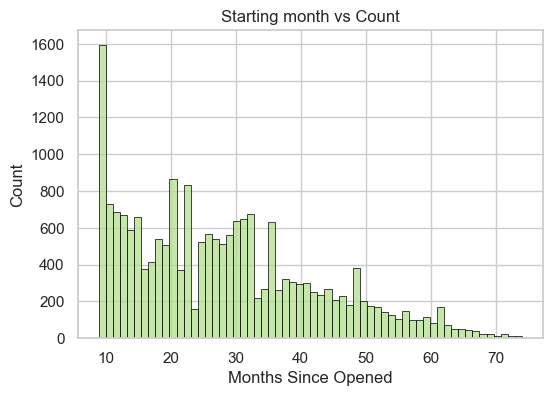

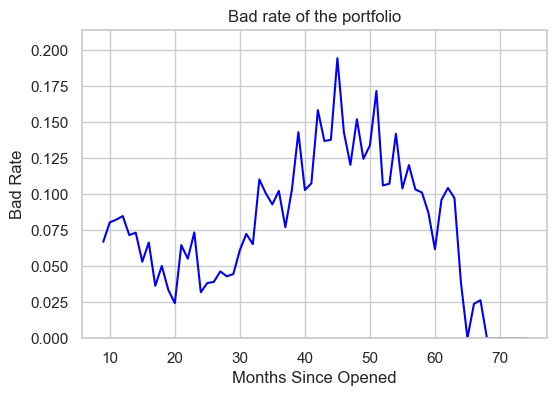

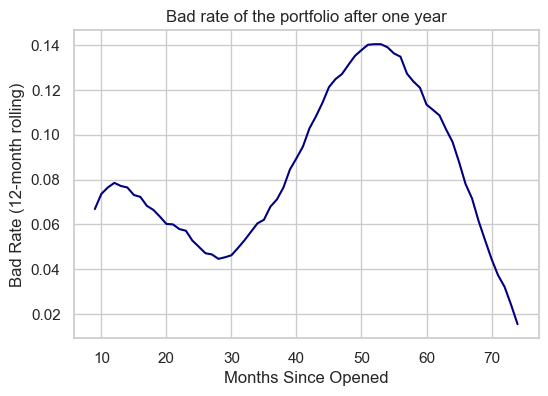

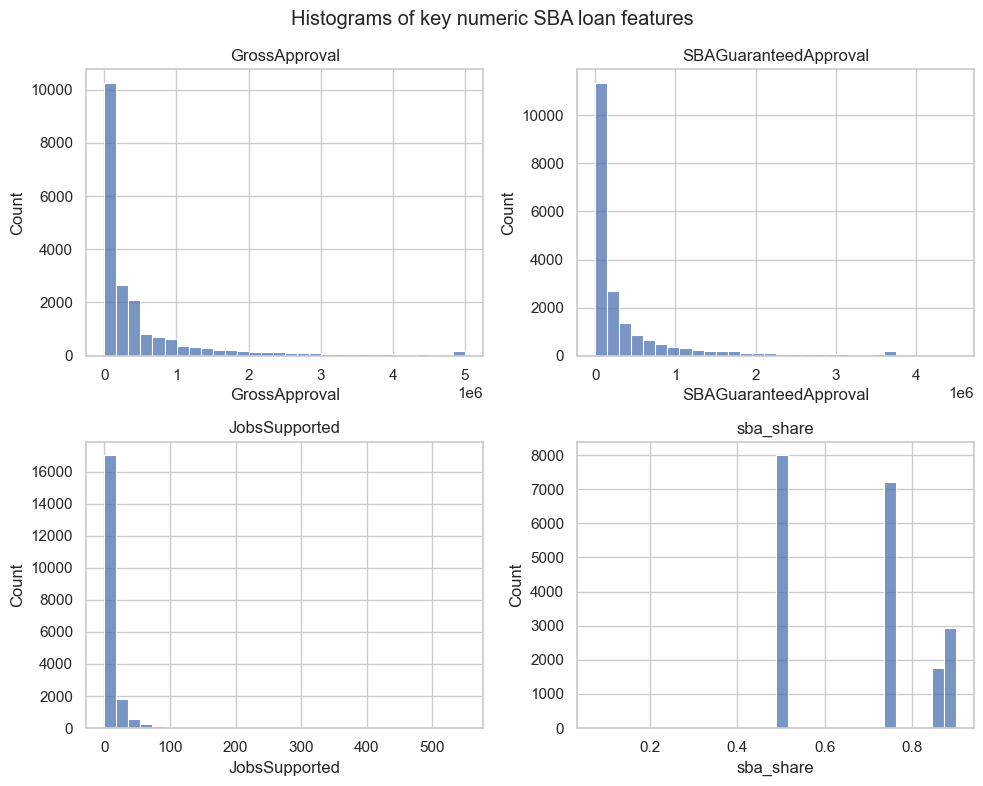

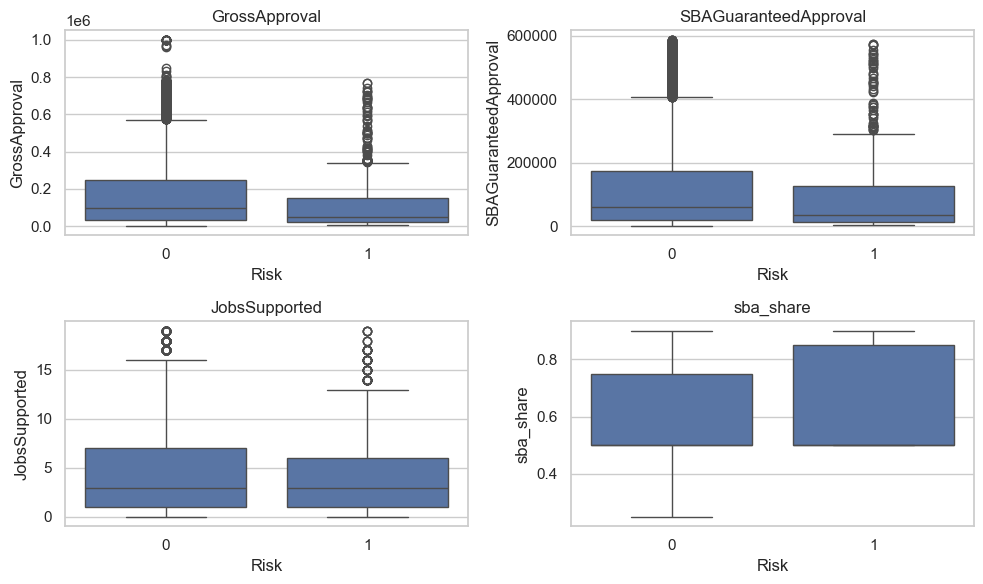

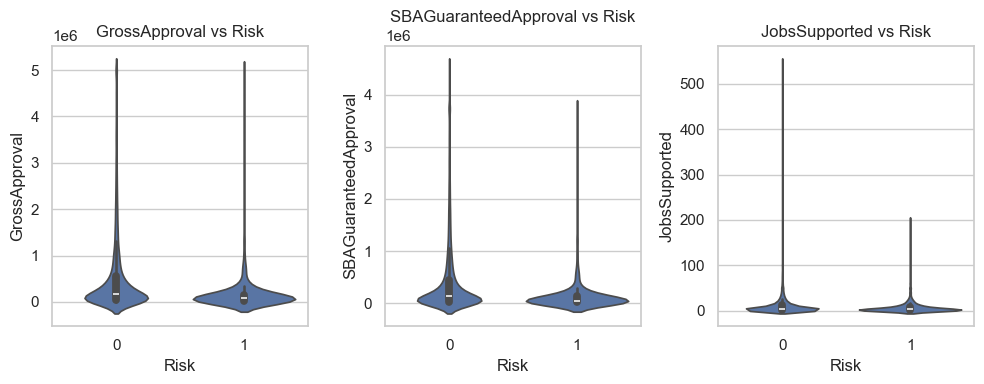

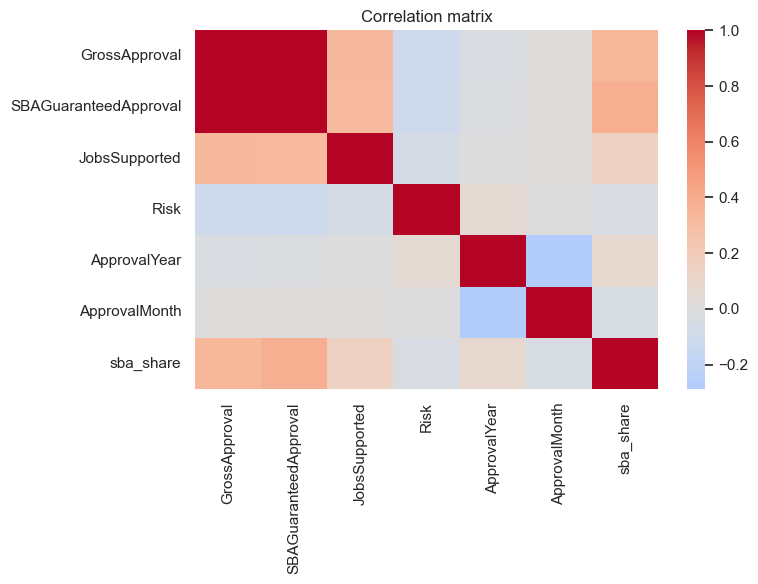

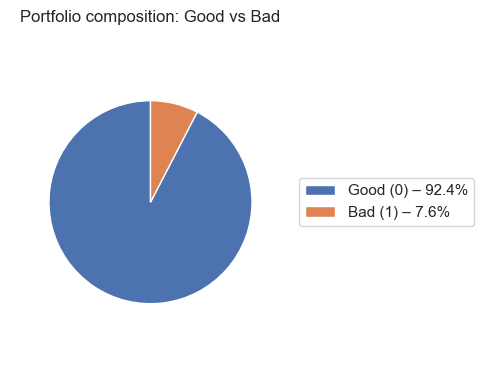

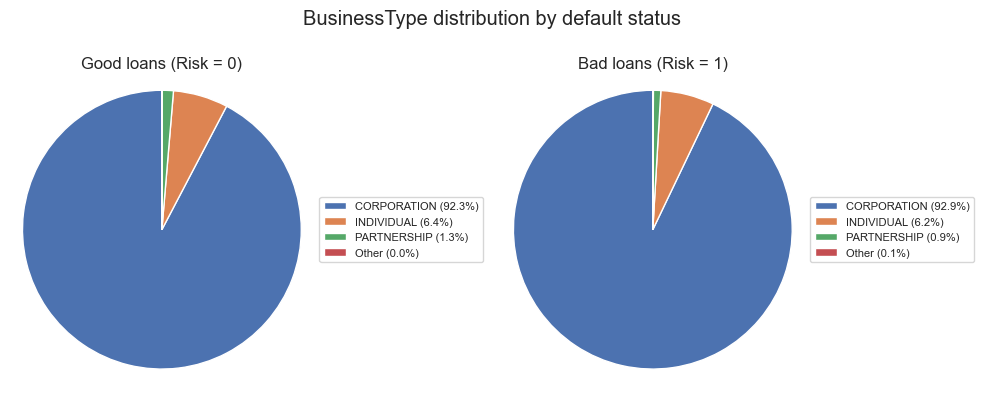

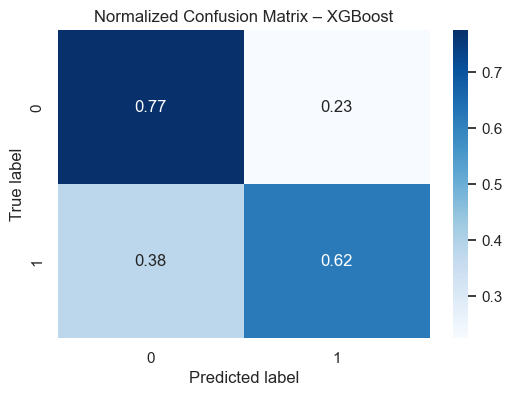

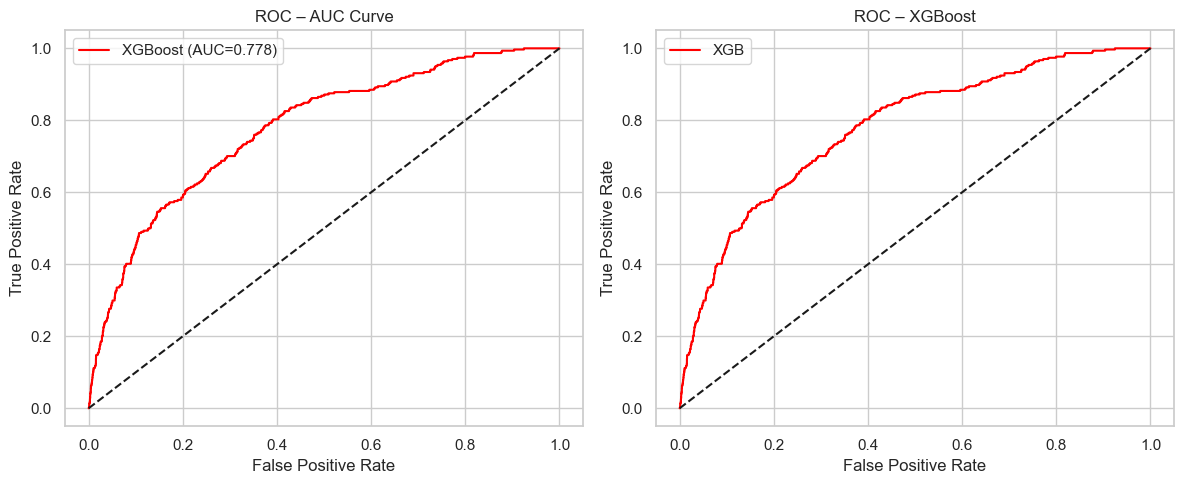

In [ ]:


# Helper: months since earliest approval 
if "ApprovalYear" in df_clean.columns and "ApprovalMonth" in df_clean.columns:
    df_time = df_clean.dropna(subset=["ApprovalYear", "ApprovalMonth"]).copy()
    base_year = int(df_time["ApprovalYear"].min())
    base_month = int(df_time["ApprovalMonth"].min())
    df_time["MonthsSinceOpened"] = (
        (df_time["ApprovalYear"] - base_year) * 12
        + (df_time["ApprovalMonth"] - base_month)
    )

    # FIGURE 1 : starting month vs count
    plt.figure()
    sns.histplot(df_time["MonthsSinceOpened"], bins=60, color="#b2df8a", edgecolor="black")
    plt.title("Starting month vs Count")
    plt.xlabel("Months Since Opened")
    plt.ylabel("Count")
    plt.show()
    

    # FIGURE 2 : bad rate of portfolio over time
    bad_rate = df_time.groupby("MonthsSinceOpened")["Risk"].mean().sort_index()
    plt.figure()
    plt.plot(bad_rate.index, bad_rate.values, color="blue")
    plt.xlabel("Months Since Opened")
    plt.ylabel("Bad Rate")
    plt.title("Bad rate of the portfolio")
    plt.ylim(0, bad_rate.max() * 1.1)
    plt.show()

    # FIGURE 3 : bad rate after one year (smoothed)
    bad_rate_rolling = bad_rate.rolling(window=12, min_periods=1).mean()
    plt.figure()
    plt.plot(bad_rate_rolling.index, bad_rate_rolling.values, color="navy")
    plt.xlabel("Months Since Opened")
    plt.ylabel("Bad Rate (12-month rolling)")
    plt.title("Bad rate of the portfolio after one year")
    plt.show()

# FIGURE 4: HISTOGRAMS OF FEATURES
num_for_box = [
    c for c in ["Term", "GrossApproval", "SBAGuaranteedApproval",
                "JobsSupported", "sba_share"]
    if c in df_clean.columns
] 
n = len(num_for_box)
cols = 2                                
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(10, 4 * rows))
axes = axes.ravel()                     

for ax, col in zip(axes, num_for_box):
    sns.histplot(df_clean[col].dropna(), bins=30, kde=False, ax=ax)
    ax.set_title(f"{col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

for j in range(len(num_for_box), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Histograms of key numeric SBA loan features", y=0.98)
plt.tight_layout()
plt.show()


# FIGURE 5 : Boxplots of numeric features
num_for_box = [c for c in ["Term","GrossApproval","SBAGuaranteedApproval",
                           "JobsSupported","sba_share"] if c in df_clean.columns]

df_box = df_clean[["Risk"] + num_for_box].copy()
for col in num_for_box:
    q1 = df_box[col].quantile(0.25)
    q3 = df_box[col].quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    df_box = df_box[(df_box[col] >= low) & (df_box[col] <= high)]

# multiple boxplots
plt.figure(figsize=(10, 6))
for i, col in enumerate(num_for_box, 1):
    plt.subplot(2, int(np.ceil(len(num_for_box)/2)), i)
    sns.boxplot(data=df_box, x="Risk", y=col)
    plt.title(col)
plt.tight_layout()
plt.show()

# FIGURE 6: Violin plots of important numeric features by default status
imp_for_violin = num_for_box[:3]
plt.figure(figsize=(10, 4))
for i, col in enumerate(imp_for_violin, 1):
    plt.subplot(1, len(imp_for_violin), i)
    sns.violinplot(data=df_clean, x="Risk", y=col, inner="box")
    plt.title(f"{col} vs Risk")
plt.tight_layout()
plt.show()

#  FIGURE 7: CORRELATION MATRIX  
num_df = df_clean.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
corr = num_df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

# FIGURE 8: PORTFOLIO COMPOSITION PIE (Good vs Bad loans)
counts = df_clean["Risk"].value_counts().sort_index()
pct = (counts / counts.sum() * 100).round(1)

labels = [f"Good (0) – {pct[0]}%", f"Bad (1) – {pct[1]}%"]

plt.figure(figsize=(5, 4))
plt.pie(counts.values, startangle=90)
plt.title("Portfolio composition: Good vs Bad")
plt.axis("equal")
plt.legend(labels, loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# FIGURE 9: PIE CHARTS - side by side for Risk = 0 and Risk = 1
def pie_by_risk_side_by_side(feature, max_categories=3):
    if feature not in df_clean.columns:
        return

    tmp = df_clean[[feature, "Risk"]].copy()
    tmp[feature] = tmp[feature].astype(str)

    # Prepare counts for Risk = 0 and Risk = 1
    counts_by_risk = {}
    for val in [0, 1]:
        counts_full = tmp[tmp["Risk"] == val][feature].value_counts()

        if counts_full.empty:
            print(f"No data for {feature} with Risk = {val}")
            counts_by_risk[val] = None
            continue

        # Top categories 
        if len(counts_full) > max_categories:
            top = counts_full.head(max_categories)
            other_sum = counts_full.iloc[max_categories:].sum()
            if other_sum > 0:
                counts = top.copy()
                counts["Other"] = other_sum
            else:
                counts = top
        else:
            counts = counts_full

        counts_by_risk[val] = counts

    # If both are empty, nothing to plot
    if counts_by_risk[0] is None and counts_by_risk[1] is None:
        return

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    for ax, val, title_suffix in zip(
        axes,
        [0, 1],
        ["Good loans (Risk = 0)", "Bad loans (Risk = 1)"]
    ):
        counts = counts_by_risk[val]
        if counts is None:
            ax.set_visible(False)
            continue

        pct = (counts / counts.sum() * 100).round(1)
        labels = [f"{cat} ({p}%)" for cat, p in zip(counts.index, pct)]

        wedges, _ = ax.pie(counts.values, startangle=90)
        ax.set_title(title_suffix)
        ax.axis("equal")
        ax.legend(
            wedges,
            labels,
            loc="center left",
            bbox_to_anchor=(1, 0.5),
            fontsize=8
        )

    fig.suptitle(f"{feature} distribution by default status", y=0.98)
    plt.tight_layout()
    plt.show()

# Calling for each categorical feature you care about
for f in ["BusinessType", "LoanDeliveryMethod"]:
    pie_by_risk_side_by_side(f)


# Figure 11 – Normalized confusion matrix of tuned XGBoost 
cm = confusion_matrix(y_test, y_pred, normalize="true")
plt.figure()
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Normalized Confusion Matrix – XGBoost")
plt.show()

#  ROC curves 
fpr, tpr, _ = roc_curve(y_test, y_score)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#  ROC–AUC curve 
axes[0].plot(fpr, tpr, label=f"XGBoost (AUC={metrics['roc_auc']:.3f})", color="red")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC – AUC Curve")
axes[0].legend()

# ROC only for XGB 
axes[1].plot(fpr, tpr, color="red", label="XGB")
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC – XGBoost")
axes[1].legend()

plt.tight_layout()
plt.show()

